# Creación de mapas interactivos con Python y la librería Folium

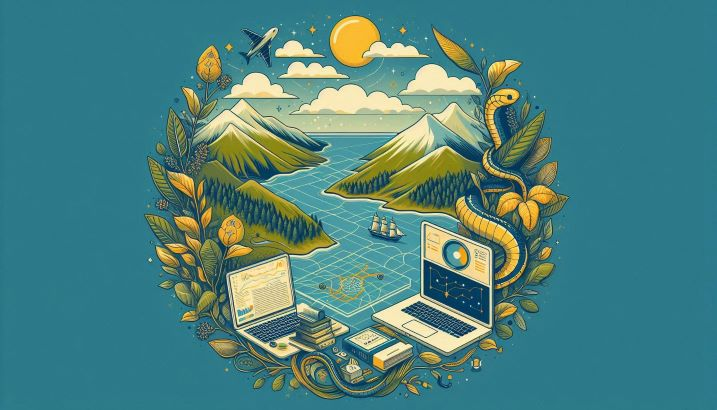

# 1. Introducción

Los mapas interactivos son recursos muy útiles en el desarrollo del trabajo. Por una parte, nos pueden servir como herramienta de validación de datos y por otra, como documento adicional que puede ser enviado a los peticionarios cuando estos solicitan datos.

Por lo general, los recursos que necesitamos serán los siguientes:

- Un *dataset* o conjunto de datos. Estos datos contendrán una o más columnas dedicadas al ámbito geográfico, como un campo Geom (o geometría) o campos de Latitud y Longitud. Serán archivos .xlsx (cuidado en caso de que contega varias hojas) o .csv.
- Las *capas* o archivos [shapefile](https://desktop.arcgis.com/es/arcmap/latest/manage-data/shapefiles/what-is-a-shapefile.htm) que queremos visualizar en nuestro mapa. Estos pueden representar zonas de pesca, áreas protegidas, zonas FAO, ZEE (Zonas Económicas Exclusivas).

Respecto a las herramientas, generalmente utilizaremos las siguientes:

- *SQL Server Management Studio*, de donde obtendremos el dataset y si lo necesitamos, alguna capa que queramos incluir en el mapa.
- [*Visual Studio Code*](https://code.visualstudio.com/) como editor donde trabajaremos con Python y las librerías propias de este lenguaje. Es muy útil trabajar en Notebooks de Jupyter como este, que, al ser una especie de cuaderno, nos permite incluir comentarios e ir ejecutando las celdas poco a poco, ideal para aprender.
- Adicionalmente, viene bien tener acceso a *QGIS* para revisar rápidamente y de forma sencilla posiciones o capas antes de trabajarlos en python.


# 2. Librerías necesarias

Por lo general, utilizaremos las siguiente librerías:

- [pandas](https://pandas.pydata.org/docs/): Librería para trabajar con datos en formato de tablas. La utilizaremos para leer archivos Excel y comprobar y limpiar columnas si hace falta.
- [geopandas](https://geopandas.org/en/stable/docs.html): Una extensión de pandas que permite trabajar con datos geográficos (puntos, líneas o polígonos). La usaremos para convertir el dataset en un GeoDataFrame con un columna geomtry (compuesta por latitud y longitud), leer capas/shapefiles y sobre todo, asegurar que todas las capas usan el mismo sistema de coordenadas ([CRS](https://support.esri.com/es-es/gis-dictionary/crs): por lo general, utilizaremos EPSG:4326)
- [folium](https://python-visualization.github.io/folium/latest/#): Librería clave, que permite crear mapas interactivos, que pueden abrirse en un navegador o guardar como .html (formato ideal para enviar). Con ella crearemos el mapa base, añadiremos las capas y personalizaremos colores, [tooltips](https://www.eniun.com/tooltip-css-pasos-crear-tooltips/) o leyendas, entre otros.
- [os](https://docs.python.org/3/library/os.html): Librería estándar de Python, que sirve para interactuar con el sistema operativo. Aunque no sea vea en el código, normalmente se incluye para comprobar rutas de archivos, unir rutas de forma segura, o crear carpetas si no existen.

Algunas extensiones muy recomendables de estas librerías son:

- [folium.plugins.HeatMap](https://python-visualization.github.io/folium/latest/user_guide/plugins/heatmap.html): Una extensión o plugin de folium para crear mapas de calor ([heatmap](https://pro.arcgis.com/es/pro-app/latest/help/mapping/layer-properties/heat-map.htm)). Muy útil para representar la densidad de puntos y para ver rápidamente dónde hay más actividad.

In [ ]:
# Carga de librerías:

import pandas as pd
import geopandas as gpd
import folium
import os
from folium.plugins import HeatMap

# Tarda aproximadamente 20 segundos

# 3. Ejemplo práctico

## 3.1 Carga de posiciones y de capas

Para ver un ejemplo concreto de elaboración de mapa interactivo, vamos a construir uno a través de las posiciones solicitadas en la consulta [#7700 - VMS_AZTI_1_2025-Atuneros congeladores y auxiliares](https://soporte.pesca.mapama.es/issues/7700), que es una consulta de principios de 2025 ya resuelta y documentada. 

Como recursos utizaremos:

- El conjunto de resultados o dataset, que se encuentra en la siguiente ruta de la carpeta común: "P:\Proyectos\CALCULO_CIERRES\CONTROL CALIDAD\2.I CONSULTAS TERMINADAS 2025\#7700 - VMS_AZTI_1_2025-Atuneros congeladores y auxiliares\Output\Versiones de informática\7700_V1.xlsx"
- Este dataset ya tiene los campos Latitud y Longitud, pero también incluye el campo Zona, que recoge las [Zonas FAO](https://fish-commercial-names.ec.europa.eu/fish-names/fishing-areas_es), por lo que vamos a incluir una capa que recoja estas zonas. Las zonas más comunes se encuentran en la ruta de la carpeta común: "P:\Proyectos\CALCULO_CIERRES\CONTROL CALIDAD\TeoríaSIPE\Programacion\Directorio GIS con QGIS\GIS_2.0". Dentro de esta carpeta, utilizaremos el shapefile "P:\Proyectos\CALCULO_CIERRES\CONTROL CALIDAD\TeoríaSIPE\Programacion\Directorio GIS con QGIS\GIS_2.0\ZonasFAO\ZonasFAO.shp"

In [ ]:
# Cargamos el excel y la capa:

ruta_excel = r"P:\Proyectos\CALCULO_CIERRES\CONTROL CALIDAD\2.I CONSULTAS TERMINADAS 2025\#7700 - VMS_AZTI_1_2025-Atuneros congeladores y auxiliares\Output\Versiones de informática\7700_V1.xlsx"
ruta_fao = r"P:\Proyectos\CALCULO_CIERRES\CONTROL CALIDAD\TeoríaSIPE\Programacion\Directorio GIS con QGIS\GIS_2.0\ZonasFAO\ZonasFAO.shp"

df = pd. read_excel(ruta_excel)   # Leemos los datos del excel gracias a la librería pandas
fao = gpd.read_file(ruta_fao)     # Leemos los datos del shapefile a través de la librería geopandas

# Tarda aproximadamente 25 segundos


## 3.2 Creación del GeoDataFrame

Para trabajar con mapas necesitamos datos geográficos. Con gdp.GeoDataFrame vamos a añadir una columna especial llamada geometry a través de las columnas de latitud y longitud, al mismo tiempo que establecemos el CRS como EPSG:4326.

In [ ]:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["Longitud"], df["Latitud"]), crs="EPSG:4326")

# Tarda aproximadamente 0 segundos

# 3.3 Creación del mapa base

Vamos a crear el mapa base, el "lienzo" sobre el que dibujaremos las posiciones y las zonas FAO. Crearemos un mapa interactivo vacío con un fondo cartográfica (llamado tile).

In [ ]:
centro = [gdf.geometry.y.mean(), gdf.geometry.x.mean()] # Calculamos el centro del mapa a través del promedio de coordenadas, para centrar el mapa

# Ahora creamos el mapa base y lo llamamos m

m = folium.Map(
    location=centro,             # Centro del mapa según los datos
    zoom_start=6,                # Nivel de zoom inicial
    tiles='CartoDB positron',    # Utilizamos este tile
    name='CartoDB Positron'
)

m                                # Visualizamos el mapa

# Tarda aproximadamente 0 segundos

# 3.4 Dibujamos los puntos del dataframe en el mapa

Vamos a visualizar sobre el mapa los puntos que vienen del Excel.

In [ ]:
for _, row in gdf.iterrows():                          # Recorremos cada fila del GeoDataFrame(gdf)
    folium.CircleMarker(                               # Creamos un círculo pequeño en el mapa y configuramos sus argumentos en las siguientes líneas (posición y aspecto visual)
        location=[row.geometry.y, row.geometry.x],
        radius=2,
        color="blue",
        fill=True,
        fill_color="blue",
        fill_opacity=0.6
    ).add_to(m)                                         # Añadimos este marcado al mapa (m) que hemos creado antes

m                                                       # Escribir m le indica a Jupyter que muestre el mapa como salida

# Tarda aproximadamente 1 minuto


# 3.5 Añadimos la capa FAO

Vamos a visualizar sobre el mapa la capa que hemos cargado previamente.

In [ ]:
# Primero nos aseguramos que el CRS sea compatible con Folium (EPSG:4326)
if fao.crs is None or fao.crs.to_string().upper() != "EPSG:4326":
    fao = fao.to_crs(epsg=4326)

# Tarda aproximadamente 0 segundos

In [ ]:
# Añadimos la capa al mapa
folium.GeoJson(                     # Dibjamos la capa de polígonos sobre el mapa
    fao,
    name="Zonas FAO",
    style_function=lambda x: {
        "color": "red",             # Color del borde
        "fillColor": "transparent", # Sin color de relleno
        "weight": 1.5               # Grosor de línea
    }
).add_to(m)                         # Añadimos la capa al mapa

m

# Tarda aproximadamente 1 minuto

# 3.6 Exportar el mapa a HTML

Ya tenemos nuestro mapa, llamado m. Lo visualizamos correctamente aquí, pero nos gustaría tenerlo en un formato que nos permita enviarlo y que, sobre todo, no pierda sus propiedades interactivas. Vamos a exportarlo a formato HTML.

In [ ]:
# Definimos la ruta de salida y le asignamos un nombre al archivo html (habrá que ajustarla según nuestra carpeta)

ruta_salida = r"P:\Proyectos\CALCULO_CIERRES\CONTROL CALIDAD\2.I CONSULTAS TERMINADAS 2025\#7700 - VMS_AZTI_1_2025-Atuneros congeladores y auxiliares\Mapa_Practico_7700.html"

# Guardamos el mapa 

m.save(ruta_salida)

# Tarda aproximadamente 1 minuto

# 3.7 Código completo

In [ ]:
# Carga de librerías:
import pandas as pd
import geopandas as gpd
import folium
import os
from folium.plugins import HeatMap


# Cargamos el excel y la capa:
ruta_excel = r"P:\Proyectos\CALCULO_CIERRES\CONTROL CALIDAD\2.I CONSULTAS TERMINADAS 2025\#7700 - VMS_AZTI_1_2025-Atuneros congeladores y auxiliares\Output\Versiones de informática\7700_V1.xlsx"
ruta_fao = r"P:\Proyectos\CALCULO_CIERRES\CONTROL CALIDAD\TeoríaSIPE\Programacion\Directorio GIS con QGIS\GIS_2.0\ZonasFAO\ZonasFAO.shp"

df = pd. read_excel(ruta_excel)                        # Leemos los datos del excel gracias a la librería pandas
fao = gpd.read_file(ruta_fao)                          # Leemos los datos del shapefile a través de la librería geopandas

# Creación del GeoDataFrame:
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df["Longitud"], df["Latitud"]), crs="EPSG:4326")


# Creación del mapa base:
centro = [gdf.geometry.y.mean(), gdf.geometry.x.mean()] # Calculamos el centro del mapa a través del promedio de coordenadas, para centrar el mapa

# Ahora creamos el mapa base y lo llamamos m
m = folium.Map(
    location=centro,                                    # Centro del mapa según los datos
    zoom_start=6,                                       # Nivel de zoom inicial
    tiles='CartoDB positron',                           # Utilizamos este tile
    name='CartoDB Positron'
)

# Dibujamos los puntso del DataFrame en el mapa:
for _, row in gdf.iterrows():                           # Recorremos cada fila del GeoDataFrame(gdf)
    folium.CircleMarker(                                # Creamos un círculo pequeño en el mapa y configuramos sus argumentos en las siguientes líneas (posición y aspecto visual)
        location=[row.geometry.y, row.geometry.x],
        radius=2,
        color="blue",
        fill=True,
        fill_color="blue",
        fill_opacity=0.6
    ).add_to(m)                                         # Añadimos este marcado al mapa (m) que hemos creado antes

# Nos aseguramos que el CRS sea compatible con Folium (EPSG:4326)
if fao.crs is None or fao.crs.to_string().upper() != "EPSG:4326":
    fao = fao.to_crs(epsg=4326)


# Añadimos la capa FAO al mapa
folium.GeoJson(                                         # Dibujamos la capa de polígonos sobre el mapa
    fao,
    name="Zonas FAO",
    style_function=lambda x: {
        "color": "red",                                 # Color del borde
        "fillColor": "transparent",                     # Sin color de relleno
        "weight": 1.5                                   # Grosor de línea
    }
).add_to(m)                                             # Añadimos la capa al mapa

m                                                       # Visualizamos el mapa aquí, en el notebook
